In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('train.csv')

In [3]:
new_df = df.copy()

In [4]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
import re
from bs4 import BeautifulSoup

PATTERN = re.compile(r'\W')

CONTRACTIONS = {
    "ain't": "am not", "aren't": "are not", "can't": "can not", "can't've": "can not have", "'cause": "because", "could've": "could have", "couldn't": "could not", "couldn't've": "could not have", "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hadn't've": "had not have", "hasn't": "has not", "haven't": "have not", "he'd": "he would", "he'd've": "he would have", "he'll": "he will", "he'll've": "he will have", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is", "i'd": "i would", "i'd've": "i would have", "i'll": "i will", "i'll've": "i will have", "i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have", "it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not", "might've": "might have", "mightn't": "might not", "mightn't've": "might not have", "must've": "must have", "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have", "o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have", "so's": "so as", "that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would", "there'd've": "there would have", "there's": "there is", "they'd": "they would", "they'd've": "they would have", "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are", "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would", "y'all'd've": "you all would have", "y'all're": "you all are", "y'all've": "you all have", "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have"
}

def preprocess(q):

    q = str(q).lower().strip()

    # Special symbols
    q = q.replace('%', ' percent ')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')
    q = q.replace('[math]', '')

    # Number normalization
    q = q.replace(',000,000,000', 'b')
    q = q.replace(',000,000', 'm')
    q = q.replace(',000', 'k')

    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)

    # Decontract
    words = []
    for word in q.split():
        words.append(CONTRACTIONS.get(word, word))

    q = ' '.join(words)

    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    # Remove HTML
    q = BeautifulSoup(q, "html.parser").get_text()

    # Remove punctuation
    q = re.sub(PATTERN, ' ', q)

    # Remove extra spaces
    q = re.sub(r'\s+', ' ', q).strip()

    return q

In [6]:
preprocess("I've already! wasn't <b>done</b>?")

'i have already was not done'

In [7]:
new_df['question1'] = new_df['question1'].apply(preprocess)
new_df['question2'] = new_df['question2'].apply(preprocess)

In [8]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0
1,1,3,4,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divided ...,0
4,4,9,10,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,0


In [9]:
new_df['q1_len'] = new_df['question1'].str.len() 
new_df['q2_len'] = new_df['question2'].str.len()

In [10]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12
1,1,3,4,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,0,48,85,10,15
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divided ...,0,48,54,11,12
4,4,9,10,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,0,73,38,13,7


In [11]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return len(w1 & w2)

In [12]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11
1,1,3,4,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,0,48,85,10,15,7
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divided ...,0,48,54,11,12,0
4,4,9,10,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,0,73,38,13,7,4


In [13]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return (len(w1) + len(w2))

In [14]:
new_df['word_total'] = new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11,23
1,1,3,4,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,0,48,85,10,15,7,24
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4,24
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divided ...,0,48,54,11,12,0,20
4,4,9,10,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,0,73,38,13,7,4,20


In [15]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11,23,0.48
1,1,3,4,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,0,48,85,10,15,7,24,0.29
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4,24,0.17
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divided ...,0,48,54,11,12,0,20,0.00
4,4,9,10,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,0,73,38,13,7,4,20,0.20


In [16]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Create only once
STOP_WORDS = ENGLISH_STOP_WORDS

def fetch_token_features(row):

    q1 = row['question1']
    q2 = row['question2']

    SAFE_DIV = 0.0001

    token_features = [0.0] * 8

    # Tokenize
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Non-stopwords
    q1_words = {word for word in q1_tokens if word not in STOP_WORDS}
    q2_words = {word for word in q2_tokens if word not in STOP_WORDS}

    # Stopwords
    q1_stops = {word for word in q1_tokens if word in STOP_WORDS}
    q2_stops = {word for word in q2_tokens if word in STOP_WORDS}

    # Common counts
    common_word_count = len(q1_words & q2_words)
    common_stop_count = len(q1_stops & q2_stops)
    common_token_count = len(set(q1_tokens) & set(q2_tokens))

    # cwc_min
    token_features[0] = common_word_count / (
        min(len(q1_words), len(q2_words)) + SAFE_DIV
    )

    # cwc_max
    token_features[1] = common_word_count / (
        max(len(q1_words), len(q2_words)) + SAFE_DIV
    )

    # csc_min
    token_features[2] = common_stop_count / (
        min(len(q1_stops), len(q2_stops)) + SAFE_DIV
    )

    # csc_max
    token_features[3] = common_stop_count / (
        max(len(q1_stops), len(q2_stops)) + SAFE_DIV
    )

    # ctc_min
    token_features[4] = common_token_count / (
        min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV
    )

    # ctc_max
    token_features[5] = common_token_count / (
        max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV
    )

    # last_word_eq
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # first_word_eq
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

In [17]:
token_features = new_df.apply(fetch_token_features, axis=1)

token_features_df = pd.DataFrame(
    token_features.tolist(),
    columns=[
        "cwc_min",
        "cwc_max",
        "csc_min",
        "csc_max",
        "ctc_min",
        "ctc_max",
        "last_word_eq",
        "first_word_eq"
    ]
)

new_df = pd.concat(
    [new_df.reset_index(drop=True), token_features_df],
    axis=1
)

In [18]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,word_total,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,23,0.48,0.999980,0.833319,0.999983,0.999983,0.916659,0.785709,0.0,1.0
1,1,3,4,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,0,48,85,10,15,...,24,0.29,0.799984,0.499994,0.599988,0.499992,0.699993,0.466664,0.0,1.0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,24,0.17,0.399992,0.333328,0.399992,0.249997,0.399996,0.285712,0.0,1.0
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divided ...,0,48,54,11,12,...,20,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,4,9,10,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,0,73,38,13,7,...,20,0.20,0.499988,0.222220,0.666644,0.499988,0.571420,0.307690,0.0,1.0


In [19]:
!pip3 install distance


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [20]:
import distance

def fetch_length_features(row):
    q1 = row['question1']
    q2 = row['question2']
    length_features = [0.0] * 3
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    # abs_len_diff
    length_features[0] = abs(
        len(q1_tokens) - len(q2_tokens)
    )

    # mean_len
    length_features[1] = (
        len(q1_tokens) + len(q2_tokens)
    ) / 2

    # longest_substr_ratio
    strs = list(distance.lcsubstrings(q1, q2))

    if len(strs) > 0:
        length_features[2] = (
            len(strs[0]) /
            (min(len(q1), len(q2)) + 1)
        )
    else:
        length_features[2] = 0.0

    return length_features

In [21]:
length_features = new_df.apply(fetch_length_features, axis=1)
length_features_df = pd.DataFrame(
    length_features.tolist(),
    columns=[
        "abs_len_diff",
        "mean_len",
        "longest_substr_ratio"
    ]
)
new_df = pd.concat(
    [new_df.reset_index(drop=True), length_features_df],
    axis=1
)

In [22]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,0.833319,0.999983,0.999983,0.916659,0.785709,0.0,1.0,2.0,13.0,0.982456
1,1,3,4,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,0,48,85,10,15,...,0.499994,0.599988,0.499992,0.699993,0.466664,0.0,1.0,5.0,12.5,0.571429
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,0.333328,0.399992,0.249997,0.399996,0.285712,0.0,1.0,4.0,12.0,0.169492
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divided ...,0,48,54,11,12,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,11.5,0.040816
4,4,9,10,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,0,73,38,13,7,...,0.222220,0.666644,0.499988,0.571420,0.307690,0.0,1.0,6.0,10.0,0.153846


In [23]:
import sys
!{sys.executable} -m pip3 install rapidfuzz

/Library/Frameworks/Python.framework/Versions/3.14/bin/python3.14: No module named pip3


In [24]:
import sys
!{sys.executable} -m pip install rapidfuzz


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [25]:
from rapidfuzz import fuzz

def fetch_fuzzy_features(row):

    q1 = row['question1']
    q2 = row['question2']

    fuzzy_features = [0.0] * 4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.ratio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [26]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis=1)

fuzzy_features_df = pd.DataFrame(
    fuzzy_features.tolist(),
    columns=[
        "fuzz_ratio",
        "fuzz_partial_ratio",
        "token_sort_ratio",
        "token_set_ratio"
    ]
)
new_df = pd.concat(
    [new_df.reset_index(drop=True), fuzzy_features_df],
    axis=1
)

In [27]:
print(new_df.shape)
new_df.head()

(404290, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,0.785709,0.0,1.0,2.0,13.0,0.982456,92.561983,100.000000,92.561983,100.000000
1,1,3,4,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,0,48,85,10,15,...,0.466664,0.0,1.0,5.0,12.5,0.571429,64.661654,76.086957,63.157895,85.714286
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,0.285712,0.0,1.0,4.0,12.0,0.169492,53.846154,56.565657,66.153846,66.153846
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divided ...,0,48,54,11,12,...,0.000000,0.0,0.0,1.0,11.5,0.040816,35.294118,38.636364,37.254902,36.170213
4,4,9,10,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,0,73,38,13,7,...,0.307690,0.0,1.0,6.0,10.0,0.153846,45.045045,64.615385,46.846847,66.666667


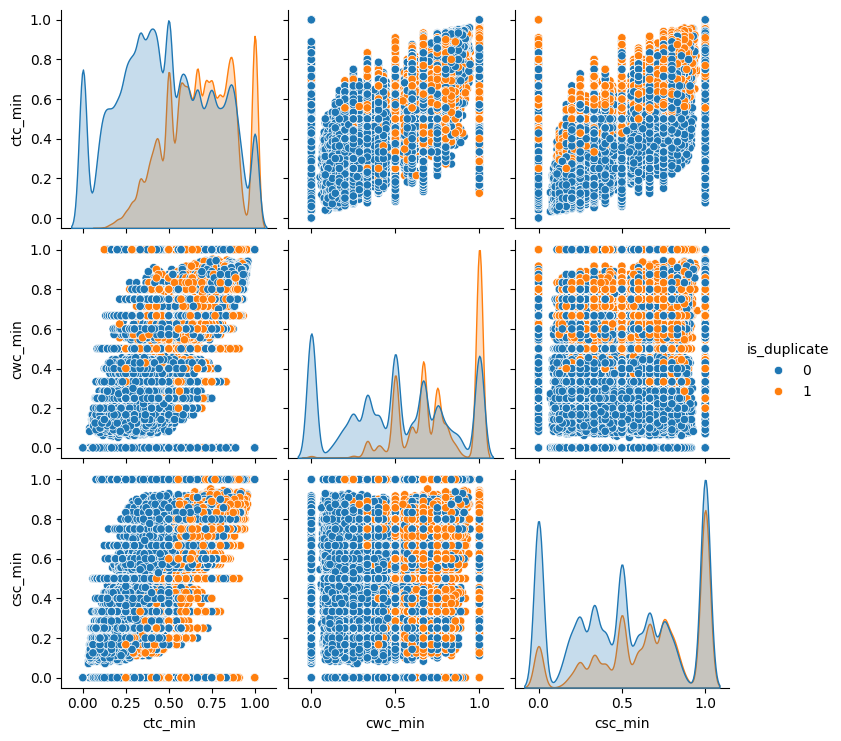

In [28]:
sns.pairplot(new_df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']],hue='is_duplicate')

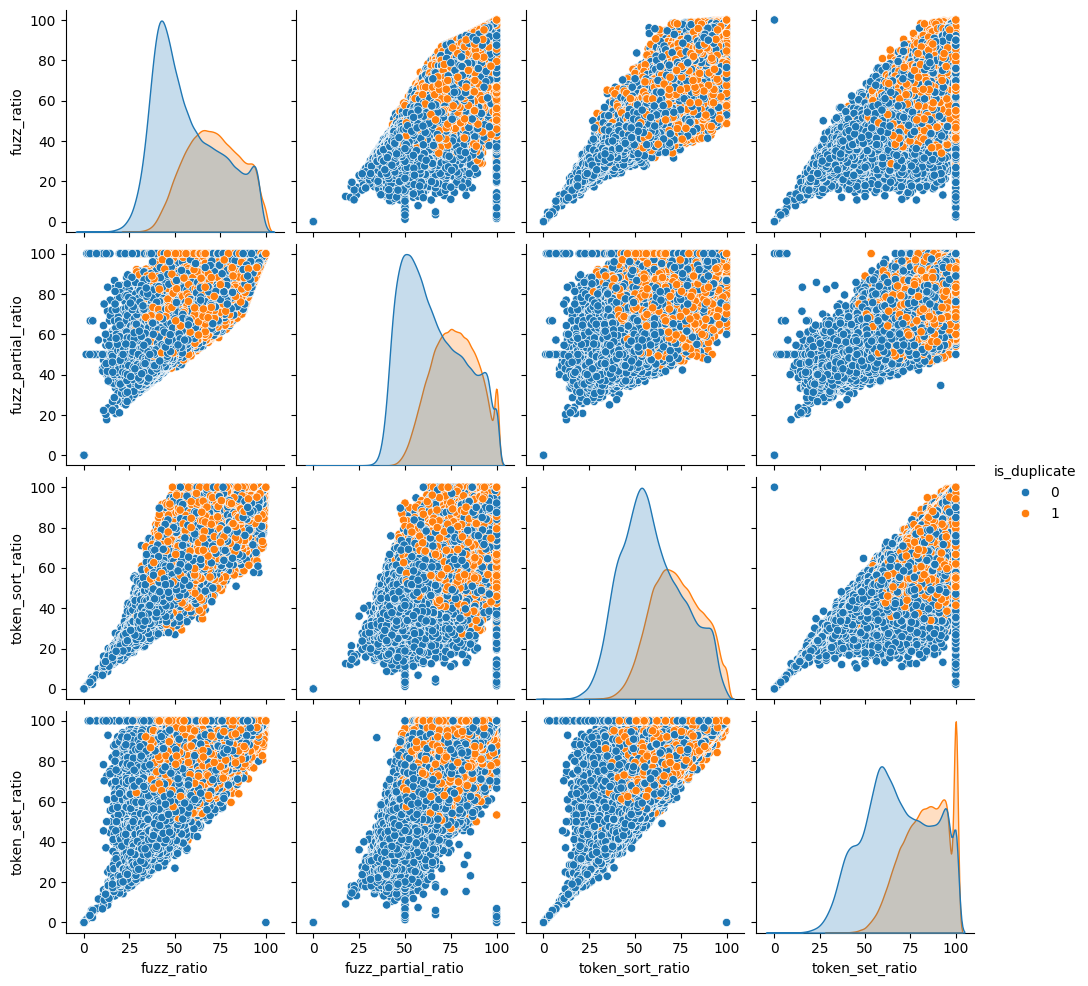

In [29]:
sns.pairplot(new_df[['fuzz_ratio', 'fuzz_partial_ratio','token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')

<Axes: >

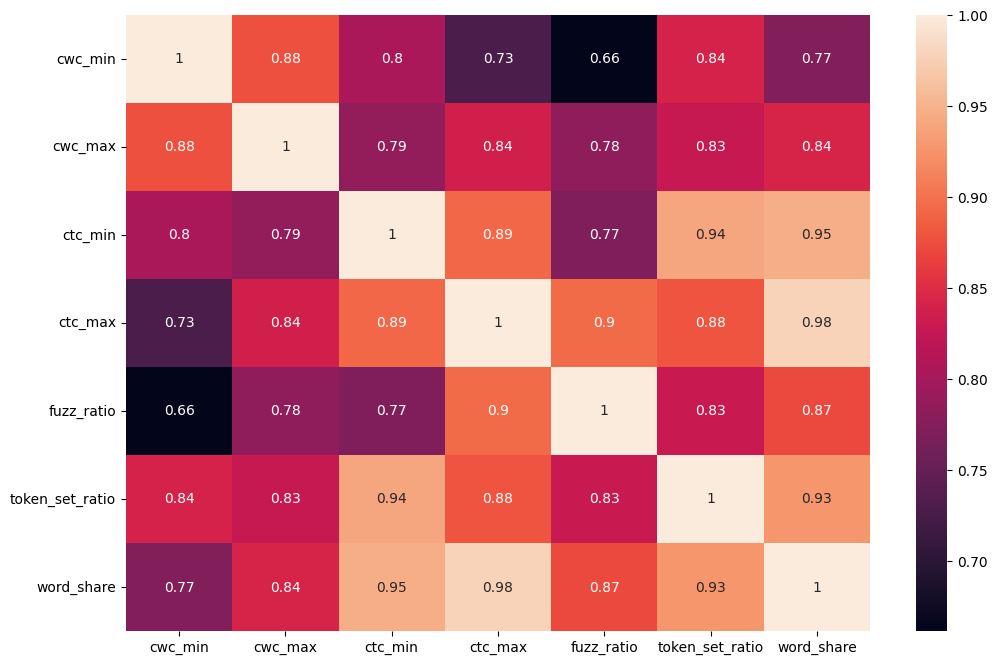

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(
    new_df[[
        'cwc_min',
        'cwc_max',
        'ctc_min',
        'ctc_max',
        'fuzz_ratio',
        'token_set_ratio',
        'word_share'
    ]].corr(),
    annot=True
)

In [33]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
0,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...
1,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...
2,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...
3,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divided ...
4,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water


In [34]:
# Save questions separately for vectorization later
ques_df = new_df[['question1', 'question2']].copy()

# Keep only engineered features + target
final_df = new_df.drop(
    columns=[
        'id',
        'qid1',
        'qid2',
        'question1',
        'question2'
    ]
)

print("ques_df shape:", ques_df.shape)
print("final_df shape:", final_df.shape)

final_df.head()

ques_df shape: (404290, 2)
final_df shape: (404290, 23)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,65,56,14,12,11,23,0.48,0.999980,0.833319,...,0.785709,0.0,1.0,2.0,13.0,0.982456,92.561983,100.000000,92.561983,100.000000
1,0,48,85,10,15,7,24,0.29,0.799984,0.499994,...,0.466664,0.0,1.0,5.0,12.5,0.571429,64.661654,76.086957,63.157895,85.714286
2,0,72,58,14,10,4,24,0.17,0.399992,0.333328,...,0.285712,0.0,1.0,4.0,12.0,0.169492,53.846154,56.565657,66.153846,66.153846
3,0,48,54,11,12,0,20,0.00,0.000000,0.000000,...,0.000000,0.0,0.0,1.0,11.5,0.040816,35.294118,38.636364,37.254902,36.170213
4,0,73,38,13,7,4,20,0.20,0.499988,0.222220,...,0.307690,0.0,1.0,6.0,10.0,0.153846,45.045045,64.615385,46.846847,66.666667


In [35]:
from sklearn.feature_extraction.text import CountVectorizer

# Merge both question columns
questions = (
    ques_df['question1'].tolist() +
    ques_df['question2'].tolist()
)

cv = CountVectorizer(
    max_features=5000,
    stop_words='english'
)

question_vectors = cv.fit_transform(questions)

split_idx = len(ques_df)

q1_arr = question_vectors[:split_idx]
q2_arr = question_vectors[split_idx:]

print(type(q1_arr))
print(q1_arr.shape)

print(type(q2_arr))
print(q2_arr.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(404290, 5000)
<class 'scipy.sparse._csr.csr_matrix'>
(404290, 5000)


In [36]:
from scipy.sparse import hstack
from scipy.sparse import csr_matrix

# handcrafted features
feature_matrix = csr_matrix(
    final_df.drop('is_duplicate', axis=1).values
)

# combine handcrafted + tfidf features
X = hstack([
    feature_matrix,
    q1_arr,
    q2_arr
])

y = final_df['is_duplicate'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (404290, 10022)
y shape: (404290,)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (323432, 10022)
X_test : (80858, 10022)
y_train: (323432,)
y_test : (80858,)


In [38]:
print(type(X_train))
print(X_train.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(323432, 10022)


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7810235227188405


In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7810235227188405
Precision: 0.7125310564439934
Recall   : 0.6820755032995008
F1 Score : 0.6969707342118775


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7545944742635237


In [42]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8099013084666947


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8099013084666947
Precision: 0.7488829311885612
Recall   : 0.729842896861287
F1 Score : 0.7392403345378051
[[43699  7306]
 [ 8065 21788]]


In [44]:
from sklearn.metrics import confusion_matrix

In [45]:
# for random forest model
confusion_matrix(y_test,y_pred)

array([[43699,  7306],
       [ 8065, 21788]])

In [46]:
y_pred1 = xgb.predict(X_test)

In [47]:
# for xgboost model
confusion_matrix(y_test,y_pred1)


array([[43699,  7306],
       [ 8065, 21788]])

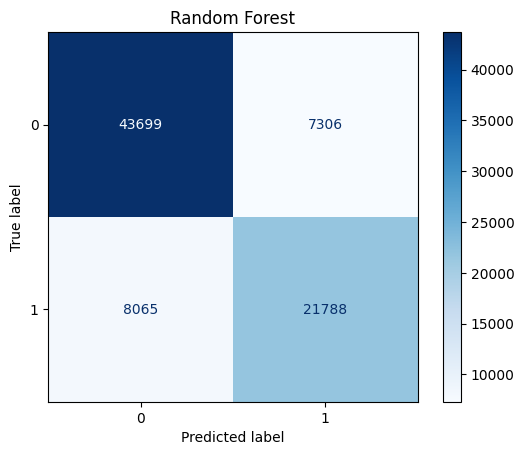

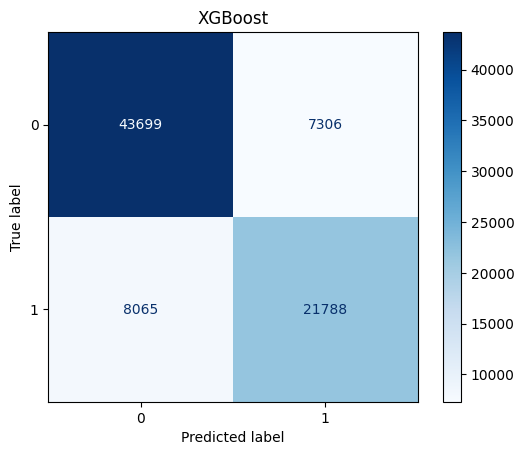

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Random Forest")
plt.show()


# XGBoost
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred1,
    cmap="Blues"
)

plt.title("XGBoost")
plt.show()

In [49]:
def test_common_words(q1, q2):
    
    w1 = set(q1.lower().strip().split())
    w2 = set(q2.lower().strip().split())

    return len(w1.intersection(w2))

In [50]:
def test_total_words(q1, q2):

    w1 = set(q1.lower().strip().split())
    w2 = set(q2.lower().strip().split())

    return len(w1) + len(w2)

In [51]:
STOP_WORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your',
    'yours','yourself','yourselves','he','him','his','himself','she',
    'her','hers','herself','it','its','itself','they','them','their',
    'theirs','themselves','what','which','who','whom','this','that',
    'these','those','am','is','are','was','were','be','been','being',
    'have','has','had','having','do','does','did','doing','a','an',
    'the','and','but','if','or','because','as','until','while','of',
    'at','by','for','with','about','against','between','into','through',
    'during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under'
}

def test_fetch_token_features(q1, q2):

    SAFE_DIV = 0.0001

    token_features = [0.0] * 8

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    q1_words = {word for word in q1_tokens if word not in STOP_WORDS}
    q2_words = {word for word in q2_tokens if word not in STOP_WORDS}

    q1_stops = {word for word in q1_tokens if word in STOP_WORDS}
    q2_stops = {word for word in q2_tokens if word in STOP_WORDS}

    common_word_count = len(q1_words & q2_words)
    common_stop_count = len(q1_stops & q2_stops)
    common_token_count = len(set(q1_tokens) & set(q2_tokens))

    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)

    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)

    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

In [52]:
def test_fetch_length_features(q1, q2):

    length_features = [0.0] * 3

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    length_features[1] = (
        len(q1_tokens) + len(q2_tokens)
    ) / 2

    try:
        strs = list(distance.lcsubstrings(q1, q2))

        length_features[2] = (
            len(strs[0]) /
            (min(len(q1), len(q2)) + 1)
        )

    except:
        length_features[2] = 0

    return length_features

In [53]:
from rapidfuzz import fuzz

def test_fetch_fuzzy_features(q1, q2):

    fuzzy_features = [0.0] * 4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.ratio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [54]:
def query_point_creator(q1, q2):

    input_query = []

    q1 = preprocess(q1)
    q2 = preprocess(q2)

    # Basic Features
    input_query.append(len(q1))
    input_query.append(len(q2))

    input_query.append(len(q1.split()))
    input_query.append(len(q2.split()))

    common_words = test_common_words(q1, q2)
    total_words = test_total_words(q1, q2)

    input_query.append(common_words)
    input_query.append(total_words)

    input_query.append(
        round(common_words/(total_words + 0.0001), 2)
    )

    # Token Features
    input_query.extend(
        test_fetch_token_features(q1, q2)
    )

    # Length Features
    input_query.extend(
        test_fetch_length_features(q1, q2)
    )

    # Fuzzy Features
    input_query.extend(
        test_fetch_fuzzy_features(q1, q2)
    )

    print("Handcrafted Features:", len(input_query))

    q1_bow = cv.transform([q1]).toarray()
    q2_bow = cv.transform([q2]).toarray()

    return np.hstack(
        (
            np.array(input_query).reshape(1, 22),
            q1_bow,
            q2_bow
        )
    )

In [55]:
q1 = 'Where is the capital of India?'
q2 = 'What is the current capital of Pakistan?'
q3 = 'Which city serves as the capital of India?'
q4 = 'What is the business capital of India?'

In [56]:
xgb.predict(query_point_creator(q1, q4))

Handcrafted Features: 22


array([1])

In [57]:
query_point_creator(q1, q4).shape

Handcrafted Features: 22


(1, 10022)

In [58]:
cv

,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"


In [59]:
!pip3 install sentence-transformers


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [60]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [61]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|████████████████████████████████████████| 103/103 [00:00<00:00, 16691.01it/s]


In [62]:
q1_embeddings = model.encode(
    new_df['question1'].astype(str).tolist(),
    batch_size=64,
    show_progress_bar=True
)

q2_embeddings = model.encode(
    new_df['question2'].astype(str).tolist(),
    batch_size=64,
    show_progress_bar=True
)

Batches: 100%|█████████████████████████████████████████████████| 6318/6318 [05:11<00:00, 20.31it/s]


In [64]:
from sklearn.metrics.pairwise import cosine_similarity

In [65]:
cos_sim = []

for i in range(len(q1_embeddings)):
    sim = cosine_similarity(
        q1_embeddings[i].reshape(1,-1),
        q2_embeddings[i].reshape(1,-1)
    )[0][0]

    cos_sim.append(sim)

cos_sim = np.array(cos_sim).reshape(-1,1)

In [66]:
abs_diff = np.abs(q1_embeddings - q2_embeddings)

In [67]:
print(abs_diff.shape)

(404290, 384)


In [68]:
X = np.hstack([
    q1_embeddings,
    q2_embeddings,
    abs_diff,
    cos_sim
])

In [69]:
print(X.shape)

(404290, 1153)


In [70]:
y = new_df['is_duplicate'].values

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [73]:
from xgboost import XGBClassifier

In [74]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [75]:
xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [76]:
y_pred = xgb.predict(X_test)

In [77]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [78]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8658883474733483
Precision: 0.8130764968547309
Recall   : 0.830011645316919
F1 Score : 0.8214567966280295


In [79]:
import pickle

pickle.dump(xgb, open("model.pkl", "wb"))

In [80]:
import os

print(os.path.getsize("model.pkl")/(1024*1024))

3.9139633178710938


In [95]:
q1 = "How do I lose weight?"
q2 = "What is the best way to reduce body fat?"

q1_emb = embedder.encode([q1])
q2_emb = embedder.encode([q2])

abs_diff = np.abs(q1_emb - q2_emb)

cos_sim = cosine_similarity(q1_emb, q2_emb)

X_test = np.hstack([
    q1_emb,
    q2_emb,
    abs_diff,
    cos_sim
])

model.predict_proba(X_test)

array([[0.11216086, 0.88783914]], dtype=float32)